# Milestone 1: Data Collection & Preprocessing
**Project:** Intelligent Support Ticket Classification with RAG
**Dataset:** MohammadOthman/mo-customer-support-tweets-945k

## Install dependencies

In [1]:
!pip install -q datasets transformers sentence-transformers pandas matplotlib seaborn wordcloud nltk tqdm

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gdown 5.2.1 requires beautifulsoup4, which is not installed.
google-generativeai 0.8.6 requires pydantic, which is not installed.
tensorflow 2.20.0 requires h5py>=3.11.0, which is not installed.
tensorflow 2.20.0 requires wrapt>=1.11.0, which is not installed.


## Imports & project structure

In [1]:
import os, re, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from tqdm import tqdm

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

for folder in ['data', 'outputs', 'notebooks']:
    os.makedirs(folder, exist_ok=True)

print('Imports done. Folders created.')

Imports done. Folders created.


## Load dataset from Hugging Face

In [2]:
HF_PATH = 'hf://datasets/MohammadOthman/mo-customer-support-tweets-945k/preprocessed_data.json'

df = pd.read_json(HF_PATH)

print(f'Shape      : {df.shape}')
print(f'Columns    : {df.columns.tolist()}')
print(f'Memory     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()

Shape      : (945278, 2)
Columns    : ['input', 'output']
Memory     : 205.0 MB


,input,output
0,is the worst customer service,I would love the chance to review the account ...
1,y’all lie about your “great” connection. 5 bar...,H there! we would definitely like to work with...
2,Since I signed up with you....Since day 1,We understand your concerns and we would like ...
3,You gonna magically change your connectivity f...,This is saddening to hear. Please shoot us a D...
4,"whenever I contact customer support, they tell...",Please send me a private message so that I can...


## Data Preprocessing

In [3]:
print('=== Data Quality Report ===')
print(f'Nulls:\n{df.isnull().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print(f'Empty inputs   : {(df["input"].str.strip() == "").sum()}')
print(f'Empty outputs  : {(df["output"].str.strip() == "").sum()}')

=== Data Quality Report ===
Nulls:
input     0
output    0
dtype: int64
Duplicate rows : 1838
Empty inputs   : 4971
Empty outputs  : 2097


In [5]:
print(f'Rows before cleaning : {len(df):,}')

# 1. Drop fully duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print(f'After dropping duplicates : {len(df):,}')

# 2. Drop rows where input or output is empty / whitespace-only
df = df[df['input'].str.strip().str.len() > 0]
df = df[df['output'].str.strip().str.len() > 0]
df = df.reset_index(drop=True)
print(f'After dropping empty rows : {len(df):,}')

# 3. Strip leading/trailing whitespace from both columns
df['input']  = df['input'].str.strip()
df['output'] = df['output'].str.strip()

# 4. Sanity re-check
print(f'\n=== Post-cleaning check ===')
print(f'Nulls      : {df.isnull().sum().sum()}')
print(f'Duplicates : {df.duplicated().sum()}')
print(f'Empty inputs  : {(df["input"].str.len() == 0).sum()}')
print(f'Empty outputs : {(df["output"].str.len() == 0).sum()}')
print(f'\nFinal clean dataset : {len(df):,} rows')

Rows before cleaning : 936,793
After dropping duplicates : 936,793
After dropping empty rows : 936,793

=== Post-cleaning check ===
Nulls      : 0
Duplicates : 0
Empty inputs  : 0
Empty outputs : 0

Final clean dataset : 936,793 rows


## Text cleaning function

In [7]:
STOP_WORDS = set(stopwords.words('english'))

def preprocess_text(text: str, remove_stopwords: bool = False) -> str:
    """Clean a single text string."""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)        # URLs
    text = re.sub(r'<[^>]+>', '', text)                  # HTML tags
    text = re.sub(r"[^a-z0-9\s'.,!?]", ' ', text)       # special chars
    text = re.sub(r'\s+', ' ', text).strip()             # whitespace
    if remove_stopwords:
        tokens = word_tokenize(text)
        text = ' '.join([t for t in tokens if t not in STOP_WORDS and len(t) > 1])
    return text


In [8]:
tqdm.pandas()
print('Cleaning inputs...')
df['input_clean']  = df['input'].progress_apply(preprocess_text)
print('Cleaning outputs...')
df['output_clean'] = df['output'].progress_apply(preprocess_text)

before = len(df)
df = df[(df['input_clean'].str.len() > 2) & (df['output_clean'].str.len() > 2)].reset_index(drop=True)
print(f'Done. Dropped {before - len(df)} empty rows. Final: {len(df):,} pairs')

Cleaning inputs...


100%|██████████| 936793/936793 [00:08<00:00, 112589.33it/s]


Cleaning outputs...


100%|██████████| 936793/936793 [00:08<00:00, 111697.63it/s]


Done. Dropped 7602 empty rows. Final: 929,191 pairs


## Token-level stats

In [9]:
df['input_len']  = df['input_clean'].apply(lambda x: len(x.split()))
df['output_len'] = df['output_clean'].apply(lambda x: len(x.split()))
df['len_ratio']  = (df['output_len'] / (df['input_len'] + 1)).round(2)

print('Input length stats (words):')
print(df['input_len'].describe().round(1))
print('\nOutput length stats (words):')
print(df['output_len'].describe().round(1))

Input length stats (words):
count    929191.0
mean         18.8
std          10.3
min           1.0
25%          11.0
50%          18.0
75%          24.0
max         111.0
Name: input_len, dtype: float64

Output length stats (words):
count    929191.0
mean         19.1
std           8.3
min           1.0
25%          14.0
50%          19.0
75%          23.0
max          62.0
Name: output_len, dtype: float64


## Save cleaned corpus

In [10]:
save_path = 'outputs/cleaned_corpus.csv'
df[['input','output','input_clean','output_clean','input_len','output_len','len_ratio']].to_csv(save_path, index=False)
print(f'Cleaned corpus saved -> {save_path}  ({os.path.getsize(save_path)/1e6:.1f} MB)')

Cleaned corpus saved -> outputs/cleaned_corpus.csv  (388.8 MB)


## Text length distribution

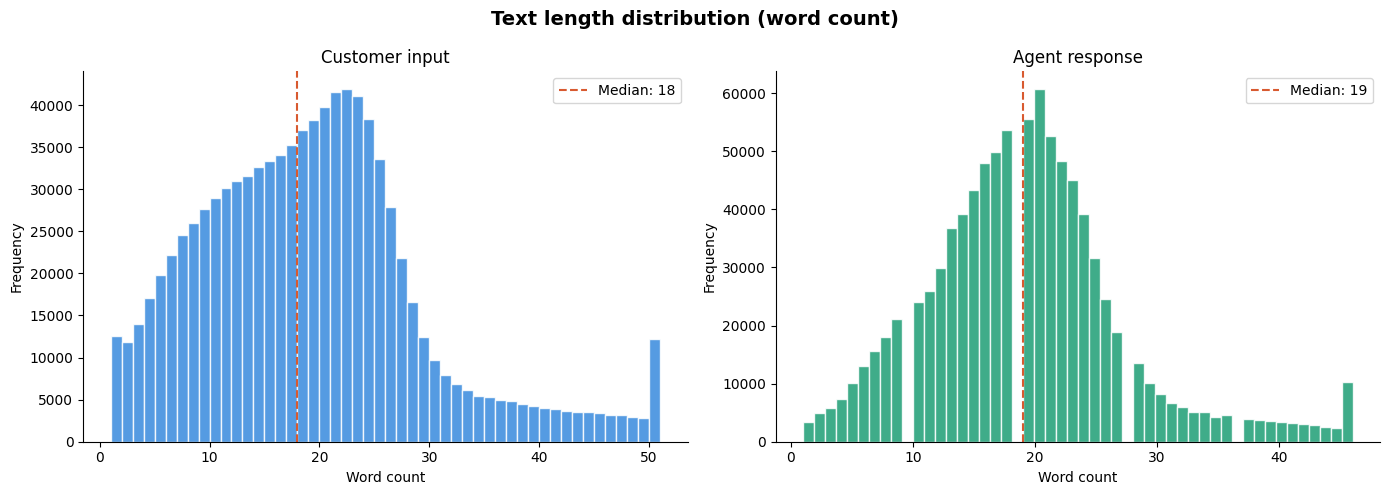

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Text length distribution (word count)', fontsize=14, fontweight='bold')

for ax, col, label, color in zip(
    axes, ['input_len','output_len'],
    ['Customer input','Agent response'],
    ['#378ADD','#1D9E75']
):
    data = df[col].clip(upper=df[col].quantile(0.99))
    ax.hist(data, bins=50, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(data.median(), color='#D85A30', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.0f}')
    ax.set_title(label)
    ax.set_xlabel('Word count')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA: Response/input length ratio

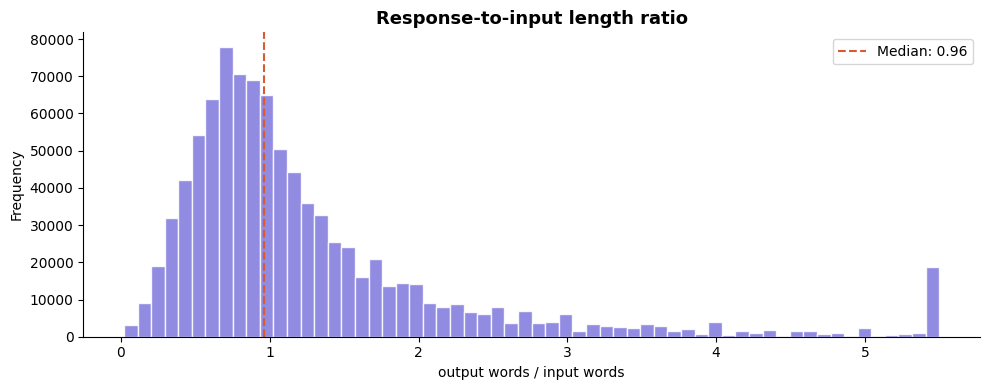

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ratio = df['len_ratio'].clip(upper=df['len_ratio'].quantile(0.98))
ax.hist(ratio, bins=60, color='#7F77DD', alpha=0.85, edgecolor='white')
ax.axvline(ratio.median(), color='#D85A30', linestyle='--', linewidth=1.5,
           label=f'Median: {ratio.median():.2f}')
ax.set_title('Response-to-input length ratio', fontsize=13, fontweight='bold')
ax.set_xlabel('output words / input words')
ax.set_ylabel('Frequency')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/length_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

## Top 30 most frequent words

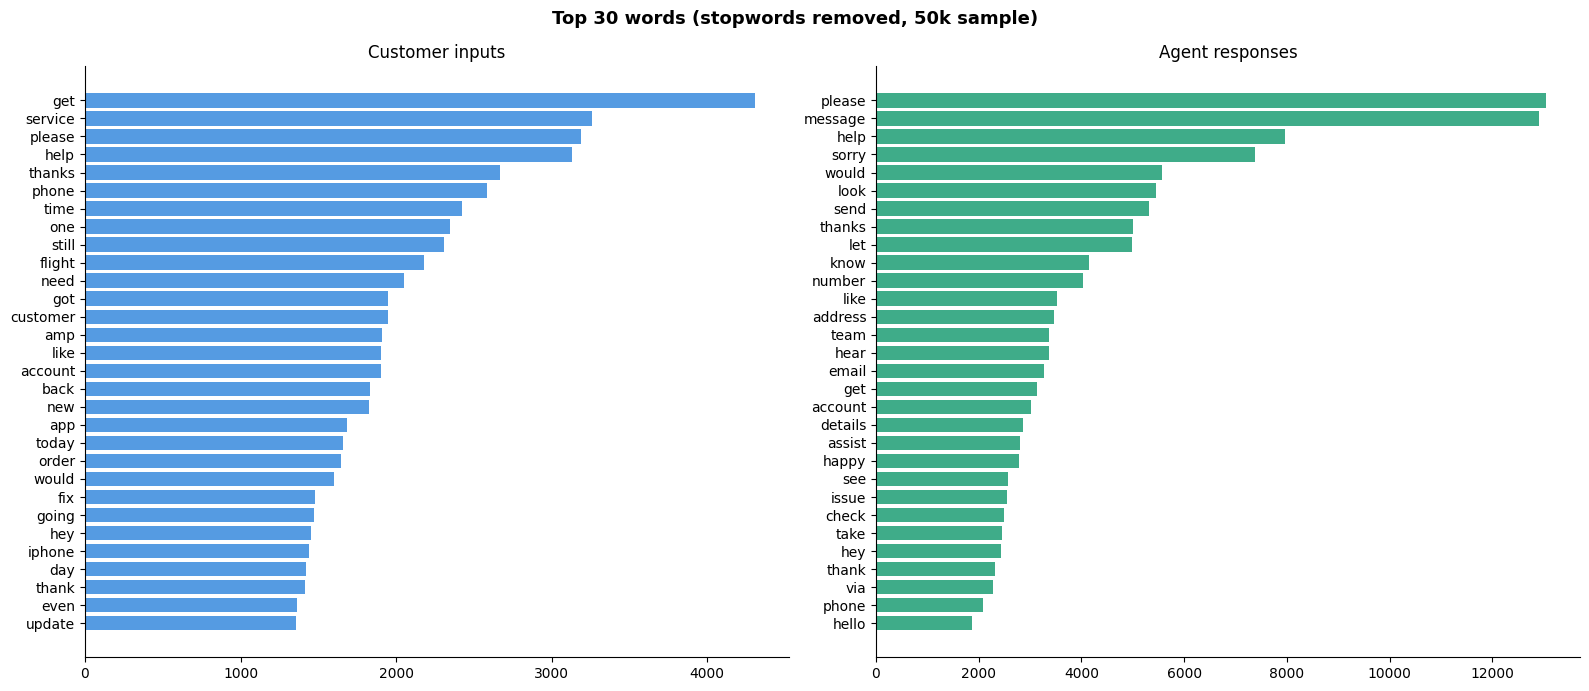

In [13]:
def get_top_words(series, n=30):
    all_words = []
    for text in series.dropna():
        tokens = word_tokenize(str(text))
        tokens = [t for t in tokens if t not in STOP_WORDS and t.isalpha() and len(t) > 2]
        all_words.extend(tokens)
    return Counter(all_words).most_common(n)

# Sample 50k rows for speed
sample_df = df.sample(min(50_000, len(df)), random_state=42)

top_input  = get_top_words(sample_df['input_clean'])
top_output = get_top_words(sample_df['output_clean'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top 30 words (stopwords removed, 50k sample)', fontsize=13, fontweight='bold')

for ax, top, label, color in zip(
    axes, [top_input, top_output],
    ['Customer inputs','Agent responses'],
    ['#378ADD','#1D9E75']
):
    words, counts = zip(*top)
    y = range(len(words)-1, -1, -1)
    ax.barh(list(y), counts, color=color, alpha=0.85)
    ax.set_yticks(list(y))
    ax.set_yticklabels(words, fontsize=10)
    ax.set_title(label)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA: Word clouds

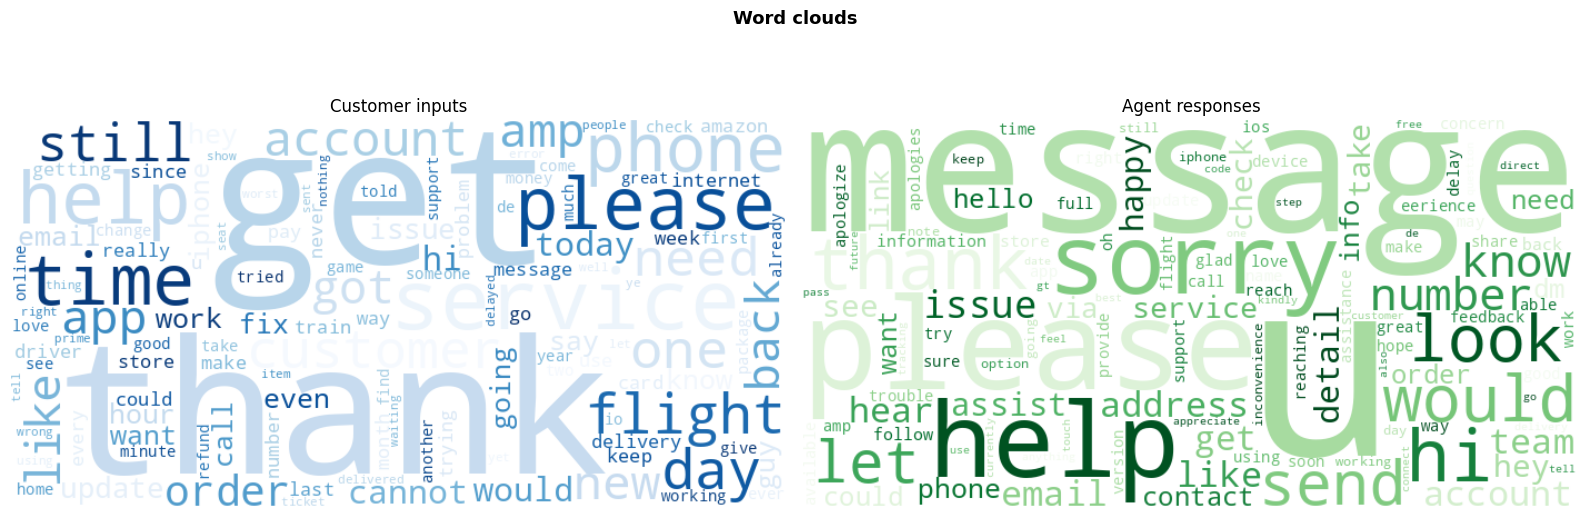

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word clouds', fontsize=13, fontweight='bold')

for ax, col, label, cmap in zip(
    axes, ['input_clean','output_clean'],
    ['Customer inputs','Agent responses'],
    ['Blues','Greens']
):
    text = ' '.join(sample_df[col].dropna().tolist())
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=cmap, stopwords=STOP_WORDS,
                   max_words=120, collocations=False).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label)

plt.tight_layout()
plt.savefig('outputs/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA summary

In [15]:
summary = pd.DataFrame({
    'Metric': ['Total pairs','Avg input len (words)','Avg output len (words)',
               'Median len ratio','Unique inputs'],
    'Value': [
        f'{len(df):,}',
        f"{df['input_len'].mean():.1f}",
        f"{df['output_len'].mean():.1f}",
        f"{df['len_ratio'].median():.2f}",
        f"{df['input_clean'].nunique():,}"
    ]
})
print('=== EDA Summary ===')
print(summary.to_string(index=False))
summary.to_csv('outputs/eda_summary.csv', index=False)

=== EDA Summary ===
                Metric   Value
           Total pairs 929,191
 Avg input len (words)    18.8
Avg output len (words)    19.1
      Median len ratio    0.96
         Unique inputs 907,100


## Generate sentence embeddings (10k sample)

In [16]:
from sentence_transformers import SentenceTransformer

MODEL_NAME   = 'all-MiniLM-L6-v2'  # 384-dim, fast, great for semantic search
EMBED_SAMPLE = 10_000

print(f'Loading: {MODEL_NAME}')
model = SentenceTransformer(MODEL_NAME)

embed_df   = df.sample(EMBED_SAMPLE, random_state=42).reset_index(drop=True)
embeddings = model.encode(
    embed_df['input_clean'].tolist(),
    batch_size=256, show_progress_bar=True, convert_to_numpy=True
)

np.save('outputs/embeddings.npy', embeddings)
embed_df[['input_clean','output_clean']].to_csv('outputs/embedding_texts.csv', index=False)

print(f'Embeddings shape : {embeddings.shape}')
print(f'Saved -> outputs/embeddings.npy & outputs/embedding_texts.csv')

Loading: all-MiniLM-L6-v2


Batches: 100%|██████████| 40/40 [00:33<00:00,  1.20it/s]

Embeddings shape : (10000, 384)
Saved -> outputs/embeddings.npy & outputs/embedding_texts.csv
